# Task # 2 : Predict Future Stock Prices

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

stock_symbol = 'NVDA'
start_date = '2024-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

stock_data = yf.download(stock_symbol, start=start_date, end=end_date, progress=False)
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.082531,49.207530,47.510550,49.156622,411254000
2024-01-03,47.484596,48.098503,47.236038,47.400746,320896000
2024-01-04,47.912838,48.413946,47.423706,47.682245,306535000
2024-01-05,49.009880,49.459082,48.220283,48.376009,415039000
2024-01-08,52.160282,52.182246,49.391206,49.424148,642510000


In [2]:
data = stock_data.copy()
feature_columns = ['Open', 'High', 'Low', 'Volume']

data['Next_Close'] = data['Close'].shift(-1)
model_data = data.dropna().reset_index()

X = model_data[feature_columns]
y = model_data['Next_Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [3]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Training samples: 496
Testing samples: 124

Features:
Price        Open       High        Low     Volume
Ticker       NVDA       NVDA       NVDA       NVDA
0       49.156622  49.207530  47.510550  411254000
1       47.400746  48.098503  47.236038  320896000
2       47.682245  48.413946  47.423706  306535000
3       48.376009  49.459082  48.220283  415039000
4       49.424148  52.182246  49.391206  642510000

Target:
0    47.484596
1    47.912838
2    49.009880
3    52.160282
4    53.045715
Name: Next_Close, dtype: float64


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [5]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train R^2: 0.4807
Test R^2: -7.9112
Train RMSE: 25.9828
Test RMSE: 45.0991


In [6]:

results = pd.DataFrame({
    'Actual_Next_Close': y_test.values,
    'Predicted_Next_Close': test_predictions
}, index=X_test.index)


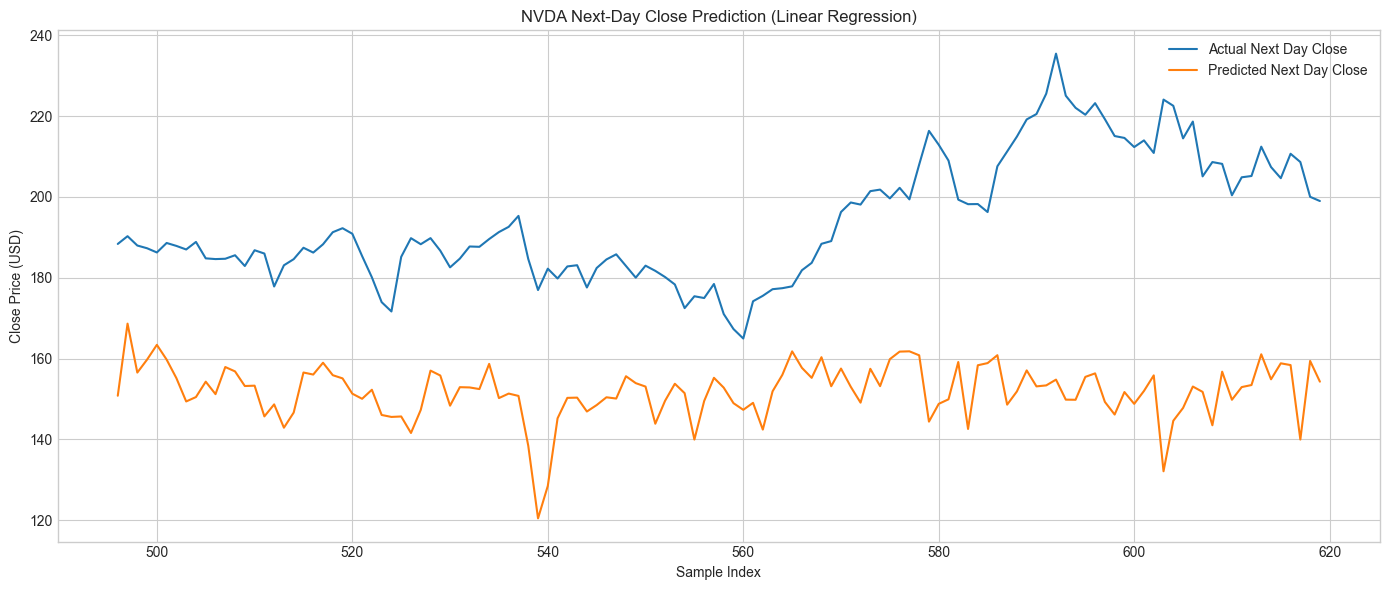

Predicted next day's close for NVDA using most recent features: $154.31


In [7]:

plt.figure(figsize=(14, 6))
plt.plot(results.index, results['Actual_Next_Close'], label='Actual Next Day Close', color='tab:blue', linewidth=1.5)
plt.plot(results.index, results['Predicted_Next_Close'], label='Predicted Next Day Close', color='tab:orange', linewidth=1.5)
plt.title(f'{stock_symbol} Next-Day Close Prediction (Linear Regression)')

plt.xlabel('Sample Index')
plt.ylabel('Close Price (USD)')

plt.legend()
plt.tight_layout()
plt.show()

prediction_index = model_data.index[-1]
latest_features = model_data[feature_columns].iloc[-1]
next_day_prediction = model.predict(latest_features.to_frame().T)[0]

print(f"Predicted next day's close for {stock_symbol} using most recent features: ${next_day_prediction:.2f}")
